# Digit Classification on MNIST

The spiral dataset in `trial_jupyter.ipynb` proved the network learns. This notebook
points the same machinery at real handwritten digits.

The layers, activations, loss and optimizer now live in `neuralnet.py`, copied
unchanged from that notebook. The data loader lives in `data/mnist.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The notebooks sit one level below the modules they use, so the project root has to
# go on the path first. Walking up to a marker file rather than hardcoding a parent
# keeps this correct whichever directory the kernel happens to start in.
project_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "neuralnet.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.mnist import load_mnist
from neuralnet import (
    ActivationReLU,
    ActivationSoftmaxLossCategoricalCrossentropy,
    LayerDense,
    OptimizerSGD,
)

rand_seed = 4

np.random.seed(rand_seed)                # legacy global, used by LayerDense weight init
rng = np.random.default_rng(rand_seed)   # modern generator, used for sampling below

## Loading the data

`load_mnist` defaults to the four original idx archives and parses the binary format
by hand. Passing `source="npz"` fetches a single pre-packed bundle instead. Running
`python data/mnist.py` downloads both and asserts they are identical.

Either way the first call downloads to `data/raw/` and caches; later calls are local.

In [2]:
train_images, train_labels, test_images, test_labels = load_mnist(source="idx")

print(f"train images  {train_images.shape}  {train_images.dtype}")
print(f"train labels  {train_labels.shape}  {train_labels.dtype}")
print(f"test images   {test_images.shape}  {test_images.dtype}")
print(f"test labels   {test_labels.shape}  {test_labels.dtype}")

print()
print(f"pixel range: {train_images.min()} to {train_images.max()}")
print(f"examples per class: {np.bincount(train_labels)}")

train images  (60000, 28, 28)  uint8
train labels  (60000,)  uint8
test images   (10000, 28, 28)  uint8
test labels   (10000,)  uint8

pixel range: 0 to 255
examples per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


## Does it actually look like digits?

The loader already asserts shapes, dtypes and the label range, but nothing so far
proves the pixels are aligned with the labels. A wrong byte offset would still pass
every one of those checks. Eyes on the data settles it.

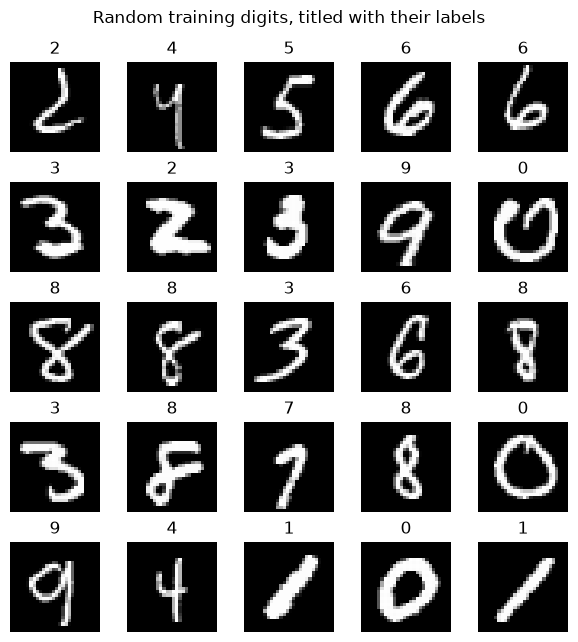

In [3]:
fig, axes = plt.subplots(5, 5, figsize=(6, 6.5))
sample = rng.choice(len(train_images), size=axes.size, replace=False)

for ax, index in zip(axes.flat, sample):
    ax.imshow(train_images[index], cmap="gray")
    ax.set_title(str(train_labels[index]))
    ax.axis("off")

fig.suptitle("Random training digits, titled with their labels")
fig.tight_layout()
plt.show()

## Preprocessing

Three changes turn the raw arrays into network input.

- **Flatten** each 28x28 image into a 784-long vector, since `LayerDense` takes one row per example.
- **Scale** the 0-255 bytes to roughly -1 to 1. Feeding raw byte values into a layer initialised for small inputs pushes the pre-activations far enough to stall training.
- **Split** off a validation set. The 10,000 test images stay untouched until the very end, so every tuning decision is made against data the final number never sees.

The split is a random slice rather than the tail of the file. MNIST's training set
draws on two different writer populations, so the ordering is not something to trust.

Casting to `float32` halves the footprint of the 60,000 by 784 matrix. The network's
weights are still `float64`, and a mixed matmul silently promotes everything back, so
the layers get cast to match when the network is built.

In [4]:
def preprocess(images):
    flat = images.reshape(len(images), -1).astype(np.float32)
    return (flat - 127.5) / 127.5


X_full = preprocess(train_images)
y_full = train_labels.astype(np.int64)

X_test = preprocess(test_images)
y_test = test_labels.astype(np.int64)

validation_size = 5000

split_rng = np.random.default_rng(rand_seed)
order = split_rng.permutation(len(X_full))     

val_index, train_index = order[:validation_size], order[validation_size:]

X_train, y_train = X_full[train_index], y_full[train_index]
X_val, y_val = X_full[val_index], y_full[val_index]

del X_full, y_full

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:<6} X {str(X.shape):<14} {X.nbytes / 1e6:6.1f} MB    y {y.shape}")

print()
print(f"value range: {X_train.min():.2f} to {X_train.max():.2f}")
print(f"class balance in validation split: {np.bincount(y_val)}")

train  X (55000, 784)    172.5 MB    y (55000,)
val    X (5000, 784)      15.7 MB    y (5000,)
test   X (10000, 784)     31.4 MB    y (10000,)

value range: -1.00 to 1.00
class balance in validation split: [474 531 523 543 433 430 503 527 511 525]


## Two checks before training for real

A network with a subtly wrong gradient does not crash. It trains, slowly, to a
mediocre accuracy, and looks like it just needs more epochs. These two checks catch
that now, while the runs are seconds rather than minutes.

One change is needed first. `LayerDense` has until now scaled its weights by a flat
0.1, which was fine for two spiral coordinates. With 784 inputs feeding each neuron,
that sum has a much wider spread, so `init="he"` scales by the fan-in instead:
each weight gets a standard deviation of sqrt(2 / n_inputs). The factor of two is the
correction for ReLU, which zeroes half its input and so halves the variance passing
through. The layers are also built as `float32` to match the images, since a mixed
matmul would silently promote everything back and throw away the memory saving.

### Check one: can it overfit 100 examples?

A network with enough capacity should be able to memorise a small subset completely.
If it cannot reach 100% on 100 examples, something is broken, and no amount of data
or tuning will fix it. This is a test of the machinery, not of learning: memorising
100 images says nothing about generalising to unseen ones.

In [5]:
subset_size = 100
X_small, y_small = X_train[:subset_size], y_train[:subset_size]

np.random.seed(rand_seed)

dense1 = LayerDense(784, 64, init="he", dtype=np.float32)
activation1 = ActivationReLU()
dense2 = LayerDense(64, 10, init="he", dtype=np.float32)
loss_activation = ActivationSoftmaxLossCategoricalCrossentropy()

optimizer = OptimizerSGD(learning_rate=0.1)

for epoch in range(1001):
    dense1.forward(X_small)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss = loss_activation.forward(dense2.output, y_small)

    accuracy = np.mean(np.argmax(loss_activation.output, axis=1) == y_small)

    if epoch % 200 == 0:
        print(f"epoch {epoch:>5}   loss {loss:.4f}   accuracy {accuracy:.3f}")

    loss_activation.backward(loss_activation.output, y_small)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    optimizer.update_params(dense1)
    optimizer.update_params(dense2)

assert accuracy == 1.0, f"cannot overfit {subset_size} examples, something is wrong"
print()
print(f"memorised all {subset_size} examples, final loss {loss:.4f}")

epoch     0   loss 3.6825   accuracy 0.150


epoch   200   loss 0.0119   accuracy 1.000
epoch   400   loss 0.0048   accuracy 1.000


epoch   600   loss 0.0029   accuracy 1.000


epoch   800   loss 0.0021   accuracy 1.000


epoch  1000   loss 0.0016   accuracy 1.000

memorised all 100 examples, final loss 0.0016


### Check two: does the analytic gradient match a numeric one?

Backpropagation is derivative bookkeeping done by hand, so it can be checked against
the definition of a derivative. Nudge one weight up and down by a tiny amount, measure
how the loss moves, and compare that slope to what `backward` claimed.

Two details make this work. The central difference, sampling both sides rather than
just forward, has error that shrinks with the square of the step rather than linearly.
And the layers here are `float64`: at `float32` precision the difference between the
two losses would be mostly rounding noise, and the check would fail on a correct
gradient.

Probing every weight would mean two forward passes each, so the larger array is
sampled rather than covered exhaustively.

In [6]:
check_rng = np.random.default_rng(rand_seed)

sample = check_rng.choice(len(X_train), size=20, replace=False)
X_check = X_train[sample].astype(np.float64)
y_check = y_train[sample]

np.random.seed(rand_seed)

check1 = LayerDense(784, 8, init="he")
check_relu = ActivationReLU()
check2 = LayerDense(8, 10, init="he")
check_loss = ActivationSoftmaxLossCategoricalCrossentropy()


def forward_loss():
    check1.forward(X_check)
    check_relu.forward(check1.output)
    check2.forward(check_relu.output)
    return check_loss.forward(check2.output, y_check)


def numeric_gradient(param, coords, eps=1e-6):
    """Central difference: (f(w + eps) - f(w - eps)) / 2 eps, one coordinate at a time."""
    slopes = np.empty(len(coords))

    for position, index in enumerate(coords):
        original = param[index]

        param[index] = original + eps
        raised = forward_loss()

        param[index] = original - eps
        lowered = forward_loss()

        param[index] = original
        slopes[position] = (raised - lowered) / (2 * eps)

    return slopes


def coords_to_probe(param, limit=200):
    every = list(np.ndindex(param.shape))
    if len(every) <= limit:
        return every
    chosen = check_rng.choice(len(every), size=limit, replace=False)
    return [every[i] for i in chosen]


# One backward pass supplies every analytic gradient below.
forward_loss()
check_loss.backward(check_loss.output, y_check)
check2.backward(check_loss.dinputs)
check_relu.backward(check2.dinputs)
check1.backward(check_relu.dinputs)

parameters = [
    ("dense1.weights", check1.weights, check1.dweights),
    ("dense1.biases", check1.biases, check1.dbiases),
    ("dense2.weights", check2.weights, check2.dweights),
    ("dense2.biases", check2.biases, check2.dbiases),
]

worst = 0.0

for name, param, analytic in parameters:
    coords = coords_to_probe(param)
    numeric = numeric_gradient(param, coords)
    claimed = np.array([analytic[index] for index in coords])

    relative = np.abs(claimed - numeric) / np.maximum(np.abs(claimed) + np.abs(numeric), 1e-12)
    worst = max(worst, relative.max())

    print(f"{name:<16} probed {len(coords):>4} of {param.size:<6} max relative error {relative.max():.2e}")

assert worst < 1e-5, f"gradient mismatch, worst relative error {worst:.2e}"
print()
print(f"backpropagation agrees with finite differences, worst case {worst:.2e}")

dense1.weights   probed  200 of 6272   max relative error 3.14e-08
dense1.biases    probed    8 of 8      max relative error 1.75e-08
dense2.weights   probed   80 of 80     max relative error 2.70e-08
dense2.biases    probed   10 of 10     max relative error 3.47e-07

backpropagation agrees with finite differences, worst case 3.47e-07


## Training on the full set

Three changes separate this from the spiral training loop.

**Mini-batches.** Pushing all 55,000 examples through in one step would allocate a
hidden-layer matrix of absurd size, and it would mean one weight update per epoch.
Each epoch instead reshuffles the index array and walks it in slices, so the network
takes hundreds of steps per pass and never sees the same batch twice.

**Momentum.** Each update carries a fraction of the previous one forward. That damps
the zig-zag across narrow valleys in the loss surface and builds speed in directions
the gradient keeps agreeing on. The catch is that it multiplies the effective step by
roughly one over one minus the momentum, so at 0.9 the steps are about ten times what
the learning rate suggests. Rates that are perfectly stable without momentum diverge
outright with it.

**Decay.** The learning rate shrinks as training proceeds: coarse steps early, fine
ones near the end. It decays per update rather than per epoch, and there are hundreds
of updates in an epoch, so useful values are far smaller than they first appear. The
first attempt here used a rate borrowed from the spiral run and lost three points of
accuracy, because it collapsed the learning rate inside three epochs.

The settings below came out of a sweep, and two results from it are worth keeping.
Rates at or above 0.1 diverged to chance, which is momentum's tenfold multiplier at
work. And decay, once it was scaled sensibly, made no difference worth having: the
best decayed run landed within noise of the best undecayed one. So it stays
implemented and switched off. A run this short does not spend long enough near the
minimum for a shrinking step to pay for itself.

In [7]:
learning_rate = 0.02
decay = 0.0
momentum = 0.9

epochs = 20
batch_size = 128
hidden_size = 128

np.random.seed(rand_seed)

dense1 = LayerDense(784, hidden_size, init="he", dtype=np.float32)
activation1 = ActivationReLU()
dense2 = LayerDense(hidden_size, 10, init="he", dtype=np.float32)
loss_activation = ActivationSoftmaxLossCategoricalCrossentropy()

optimizer = OptimizerSGD(learning_rate=learning_rate, decay=decay, momentum=momentum)

steps_per_epoch = -(-len(X_train) // batch_size)   # ceiling division

print(f"{len(X_train)} examples, {steps_per_epoch} steps per epoch, "
      f"{steps_per_epoch * epochs} updates in total")

55000 examples, 430 steps per epoch, 8600 updates in total


In [8]:
def predict_in_chunks(X_eval, y_eval, chunk=2048):
    """Forward pass only, in slices, returning mean loss and every prediction.

    Chunked because one pass over a whole split would allocate a hidden-layer
    matrix far larger than anything the training loop touches.
    """
    total_loss = 0.0
    predictions = np.empty(len(X_eval), dtype=np.int64)

    for start in range(0, len(X_eval), chunk):
        stop = start + chunk
        batch_X, batch_y = X_eval[start:stop], y_eval[start:stop]

        dense1.forward(batch_X)
        activation1.forward(dense1.output)
        dense2.forward(activation1.output)

        total_loss += loss_activation.forward(dense2.output, batch_y) * len(batch_X)
        predictions[start:stop] = np.argmax(loss_activation.output, axis=1)

    return total_loss / len(X_eval), predictions


def evaluate(X_eval, y_eval):
    loss, predictions = predict_in_chunks(X_eval, y_eval)
    return loss, np.mean(predictions == y_eval)

In [9]:
batch_rng = np.random.default_rng(rand_seed)
history = []

for epoch in range(1, epochs + 1):
    shuffled = batch_rng.permutation(len(X_train))

    epoch_loss = 0.0
    epoch_correct = 0

    for start in range(0, len(shuffled), batch_size):
        batch = shuffled[start:start + batch_size]
        batch_X, batch_y = X_train[batch], y_train[batch]

        dense1.forward(batch_X)
        activation1.forward(dense1.output)
        dense2.forward(activation1.output)
        loss = loss_activation.forward(dense2.output, batch_y)

        epoch_loss += loss * len(batch)
        epoch_correct += np.sum(np.argmax(loss_activation.output, axis=1) == batch_y)

        loss_activation.backward(loss_activation.output, batch_y)
        dense2.backward(loss_activation.dinputs)
        activation1.backward(dense2.dinputs)
        dense1.backward(activation1.dinputs)

        optimizer.pre_update_params()
        optimizer.update_params(dense1)
        optimizer.update_params(dense2)
        optimizer.post_update_params()

    train_loss = epoch_loss / len(X_train)
    train_accuracy = epoch_correct / len(X_train)
    val_loss, val_accuracy = evaluate(X_val, y_val)

    history.append({
        "epoch": epoch,
        "learning_rate": optimizer.current_learning_rate,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
    })

    print(f"epoch {epoch:>3}   lr {optimizer.current_learning_rate:.4f}   "
          f"train loss {train_loss:.4f} acc {train_accuracy:.4f}   "
          f"val loss {val_loss:.4f} acc {val_accuracy:.4f}")

epoch   1   lr 0.0200   train loss 0.3722 acc 0.8840   val loss 0.2403 acc 0.9264


epoch   2   lr 0.0200   train loss 0.1961 acc 0.9416   val loss 0.1987 acc 0.9390


epoch   3   lr 0.0200   train loss 0.1441 acc 0.9565   val loss 0.1439 acc 0.9566


epoch   4   lr 0.0200   train loss 0.1166 acc 0.9647   val loss 0.1402 acc 0.9562


epoch   5   lr 0.0200   train loss 0.0991 acc 0.9695   val loss 0.1150 acc 0.9636


...

epoch  16   lr 0.0200   train loss 0.0340 acc 0.9894   val loss 0.0972 acc 0.9744


epoch  17   lr 0.0200   train loss 0.0292 acc 0.9910   val loss 0.0907 acc 0.9754


epoch  18   lr 0.0200   train loss 0.0282 acc 0.9911   val loss 0.0966 acc 0.9732


epoch  19   lr 0.0200   train loss 0.0266 acc 0.9913   val loss 0.0994 acc 0.9744


epoch  20   lr 0.0200   train loss 0.0230 acc 0.9929   val loss 0.0946 acc 0.9756


### Learning curves

The gap between the two lines is the thing to read. Training accuracy pulling above
validation accuracy by a widening margin means the network is memorising rather than
generalising. Both still climbing together means it is underfitting and has room left.

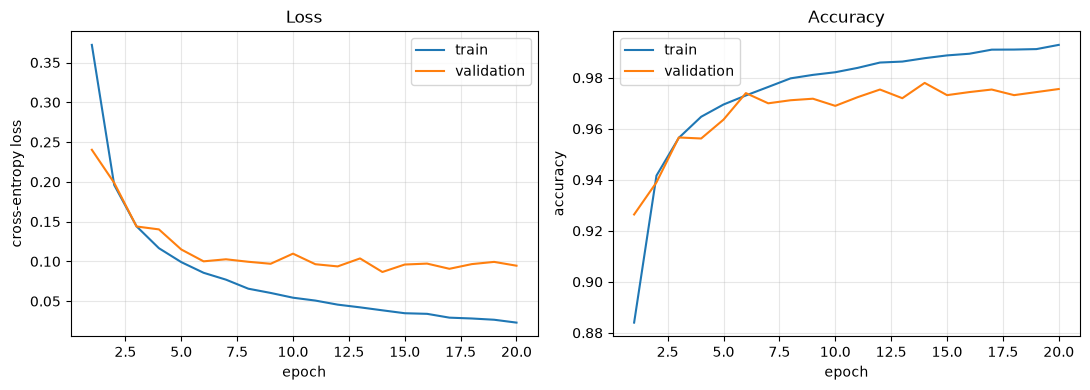

In [10]:
epoch_axis = [record["epoch"] for record in history]

fig, (loss_ax, accuracy_ax) = plt.subplots(1, 2, figsize=(11, 4))

loss_ax.plot(epoch_axis, [r["train_loss"] for r in history], label="train")
loss_ax.plot(epoch_axis, [r["val_loss"] for r in history], label="validation")
loss_ax.set_xlabel("epoch")
loss_ax.set_ylabel("cross-entropy loss")
loss_ax.set_title("Loss")
loss_ax.legend()
loss_ax.grid(alpha=0.3)

accuracy_ax.plot(epoch_axis, [r["train_accuracy"] for r in history], label="train")
accuracy_ax.plot(epoch_axis, [r["val_accuracy"] for r in history], label="validation")
accuracy_ax.set_xlabel("epoch")
accuracy_ax.set_ylabel("accuracy")
accuracy_ax.set_title("Accuracy")
accuracy_ax.legend()
accuracy_ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## The test set, once

Every decision up to here was made against the validation split. This is the first and
only time the test images are touched, which is what makes the number below an estimate
of performance on unseen data rather than a target that has been tuned toward.

In [11]:
test_loss, test_predictions = predict_in_chunks(X_test, y_test)
test_accuracy = np.mean(test_predictions == y_test)

print(f"validation accuracy {history[-1]['val_accuracy']:.4f}")
print(f"test accuracy       {test_accuracy:.4f}")
print(f"test loss           {test_loss:.4f}")
print(f"errors              {np.sum(test_predictions != y_test)} of {len(y_test)}")

validation accuracy 0.9756
test accuracy       0.9773
test loss           0.0782
errors              227 of 10000


### Which digits does it confuse?

Overall accuracy hides the shape of the failures. The confusion matrix puts true labels
down the rows and predictions across the columns, so everything off the diagonal is a
mistake, and reading along a row shows what a given digit gets mistaken for.

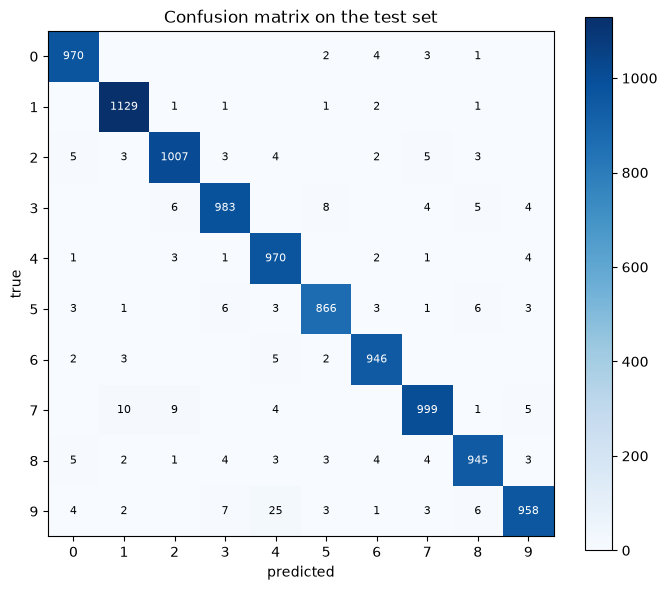

most common confusions:
  9 read as 4: 25 times
  7 read as 1: 10 times
  7 read as 2: 9 times
  3 read as 5: 8 times
  9 read as 3: 7 times


In [12]:
confusion = np.zeros((10, 10), dtype=np.int64)
np.add.at(confusion, (y_test, test_predictions), 1)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(confusion, cmap="Blues")

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix on the test set")

for true_label in range(10):
    for predicted in range(10):
        count = confusion[true_label, predicted]
        if count:
            ax.text(predicted, true_label, str(count), ha="center", va="center",
                    fontsize=8, color="white" if count > confusion.max() / 2 else "black")

fig.colorbar(image, ax=ax)
fig.tight_layout()
plt.show()

off_diagonal = confusion.copy()
np.fill_diagonal(off_diagonal, 0)

ranked = np.argsort(off_diagonal, axis=None)[::-1][:5]

print("most common confusions:")
for flat_index in ranked:
    true_label, predicted = np.unravel_index(flat_index, off_diagonal.shape)
    print(f"  {true_label} read as {predicted}: {off_diagonal[true_label, predicted]} times")

### The most confident mistakes

Sorting the errors by the probability the network assigned to its wrong answer surfaces
the cases where it was not merely uncertain but wrong and sure of it. Several of these
turn out to be genuinely ambiguous handwriting rather than model failures.

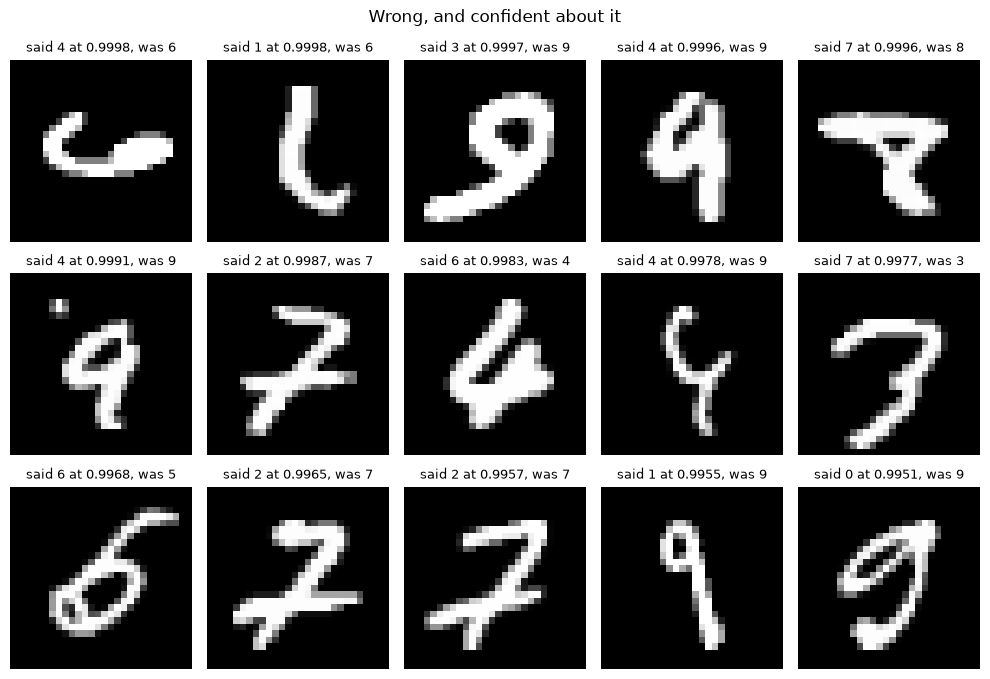

In [13]:
# Re-run the forward pass keeping the full probability rows, not just the argmax.
probabilities = np.empty((len(X_test), 10), dtype=np.float32)

for start in range(0, len(X_test), 2048):
    stop = start + 2048
    dense1.forward(X_test[start:stop])
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y_test[start:stop])
    probabilities[start:stop] = loss_activation.output

wrong = np.flatnonzero(test_predictions != y_test)
confidence = probabilities[wrong, test_predictions[wrong]]
most_confident = wrong[np.argsort(confidence)[::-1][:15]]

fig, axes = plt.subplots(3, 5, figsize=(10, 7))

for ax, index in zip(axes.flat, most_confident):
    said = test_predictions[index]
    ax.imshow(X_test[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"said {said} at {probabilities[index, said]:.4f}, was {y_test[index]}",
                 fontsize=9)
    ax.axis("off")

fig.suptitle("Wrong, and confident about it")
fig.tight_layout()
plt.show()